In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
  number1: int
  operations: str
  number2: int
  finalNumber: int


In [6]:
def add(state: AgentState) -> AgentState:
  state["finalNumber"]= state["number1"] + state["number2"]
  return state

def subtract(state: AgentState) -> AgentState:
  state["finalNumber"]= state["number1"] - state["number2"]
  return state


def decide_next_node(state: AgentState) -> AgentState:
  if state["operations"]== "+":
    return "addtional_operations"  # We return the edge name to the next node
  
  elif state["operations"] == "-":
    return "subtraction_operations"  # We return the edge name to the next node
     
  

In [11]:
graph= StateGraph(AgentState)
graph.add_node("add_node", add)
graph.add_node("subtraction_node", subtract)

graph.add_node("router", lambda state: state)  # This node will just pass the state through

graph.add_edge(START, "router")

graph.add_conditional_edges(
  "router",
  decide_next_node,

  { 
    # edge: node
    "addtional_operations": "add_node",
    "subtraction_operations": "subtraction_node"
  }
)


graph.add_edge("add_node", END)
graph.add_edge("subtraction_node", END)


app= graph.compile()



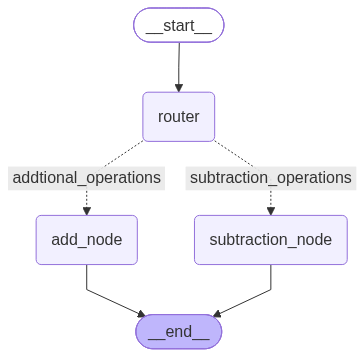

In [12]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
initial_state= AgentState(number1=10, operations="+", number2=5)
print(app.invoke(initial_state))  # This will perform addition and return the final state

{'number1': 10, 'operations': '+', 'number2': 5, 'finalNumber': 15}
